# Overfitting  
When the model over-learns the training data instead of general domain concepts.  
Model performs well on training data but fails on test data.  
Model accuracy for training data is much different/highter than that for testing data.  

In [17]:
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_moons
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

In [52]:
# Load data

X,y = make_moons(
    n_samples=1000,
    noise=0.25, # 25% noise
    random_state=42,
)

# print(X)
# print(y)

In [48]:
# Split data

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.33, random_state=42)


In [53]:
# Train model with different depts to find the best tree depth

depths = list(range(1,16))

train_accuracies = []
test_accuracies = []

for d in depths:
    model = DecisionTreeClassifier(
        max_depth=d,
        random_state=42
    )

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    train_accuracy = accuracy_score(y_train, train_pred)
    train_accuracies.append(train_accuracy)
    
    test_pred = model.predict(X_test)
    test_accuracy = accuracy_score(y_test, test_pred)
    test_accuracies.append(test_accuracy)

# test_accuracies

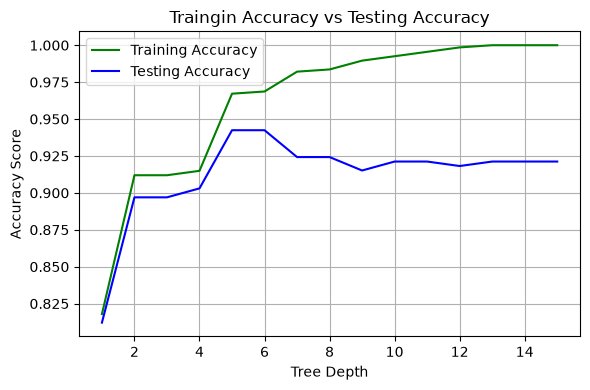

In [54]:
# To visualize the model accuracies with training and testing data

plt.figure(figsize=(6,4))

plt.plot(depths, train_accuracies, color="green", label="Training Accuracy")
plt.plot(depths, test_accuracies, color="blue", label="Testing Accuracy")

plt.title("Traingin Accuracy vs Testing Accuracy")
plt.xlabel("Tree Depth")
plt.ylabel("Accuracy Score")

plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

In [55]:
# Get the tree depth for which the test accuracy is highest

optimal_tree_depth = depths[np.argmax(test_accuracies)]

print(f"Optimal tree depth is {optimal_tree_depth}")

Optimal tree depth is 5
